# Final Project Example Problems

In [ ]:
# import libraries
import numpy as np
import pysindy
import pysr

## Example 1: Using PySR (non-dynamical system)

c:\Users\reyna\source\repos\Scientific-Machine-Learning-7750\.venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...


  Data shape : (300, 3)
  y range    : [-1.804, 2.858]
  True eq    : sin(x0²) + cos(x1³) + sin(x2)


[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.023e+00  0.000e+00  y = 0.91346
2           8.300e-01  2.087e-01  y = cos(x₁)
3           7.051e-01  1.631e-01  y = x₂ + 0.98992
4           5.169e-01  3.104e-01  y = cos(x₁) + x₂
5           3.460e-01  4.016e-01  y = tan(cos(x₁)) + x₂
6           2.882e-01  1.826e-01  y = (cos(x₁) / 0.59539) + x₂
8           2.460e-01  7.921e-02  y = ((cos(x₁) / 0.43142) + -0.49387) + x₂
10          2.121e-01  7.404e-02  y = ((sin(cos(x₁)) / 0.43142) + sin(x₂)) + -0.49387
12          1.055e-01  3.491e-01  y = (x₂ + -2.1432) + ((cos(cos(x₀)) + cos(x₁)) / 0.44918)
───────────────────────────────────────────────────────────────────────────────────────────────────

  HALL OF FAME
  Complexity        Loss     Score  Equation
  --------------------------------------------------------
           1     1.02263    0.0000  0.9134604
           2     0.83002

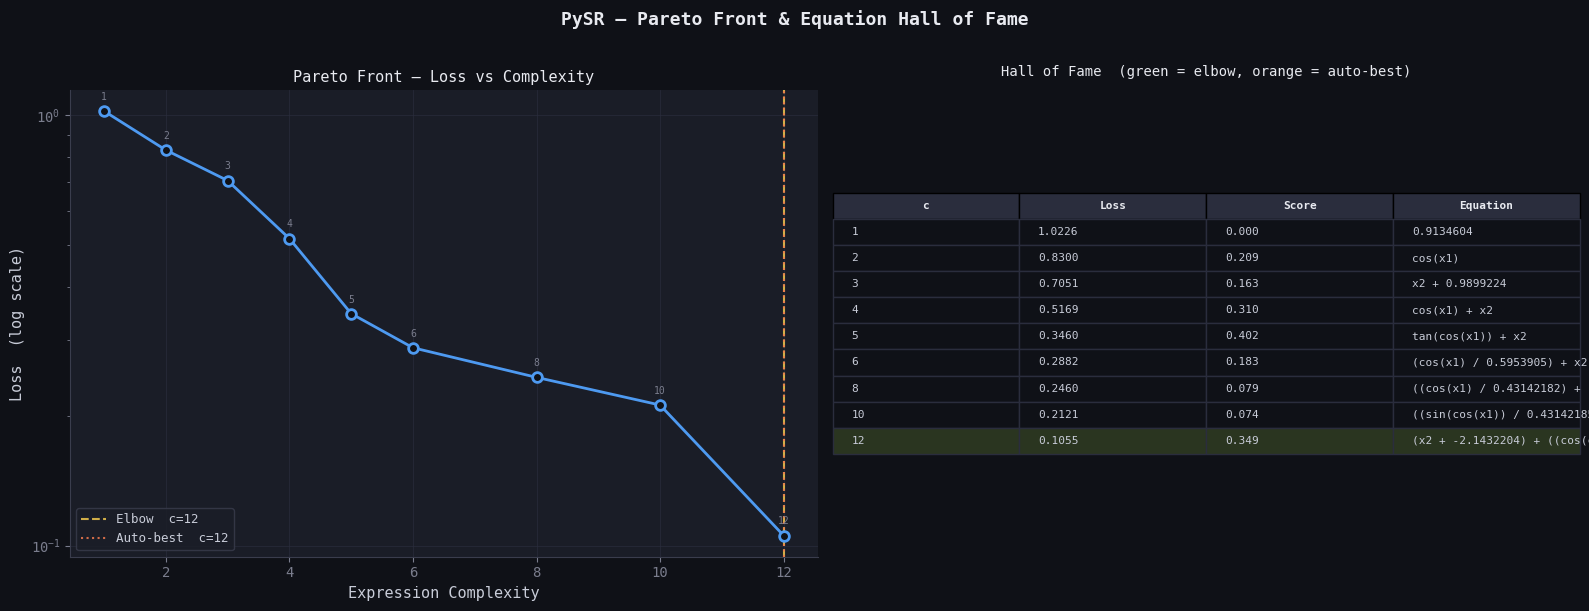

  Saved → fig1_pareto_front.png


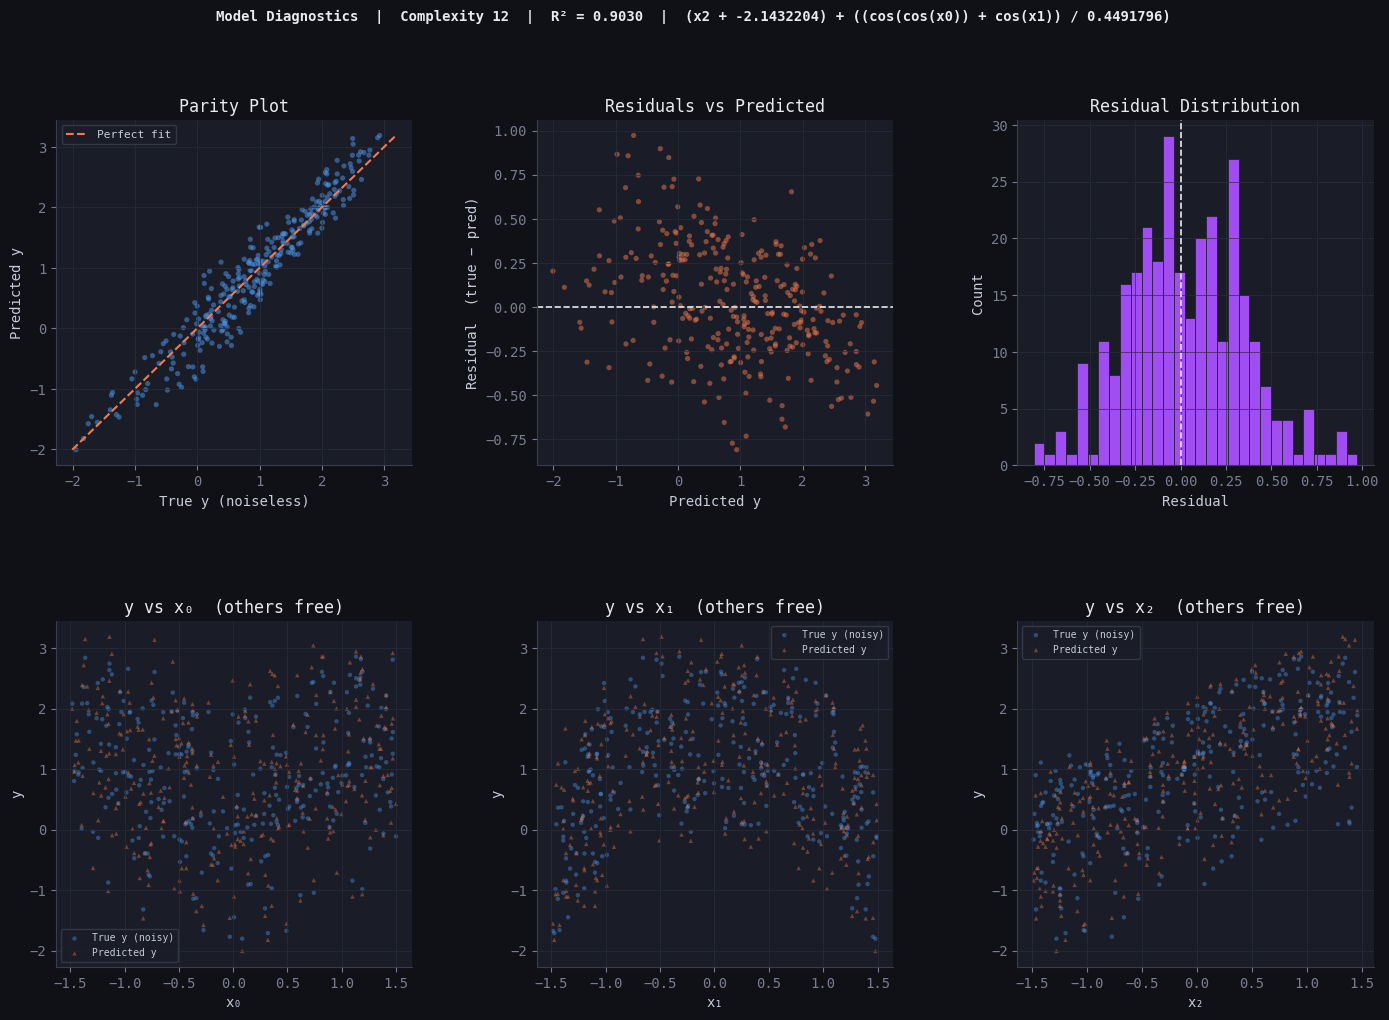

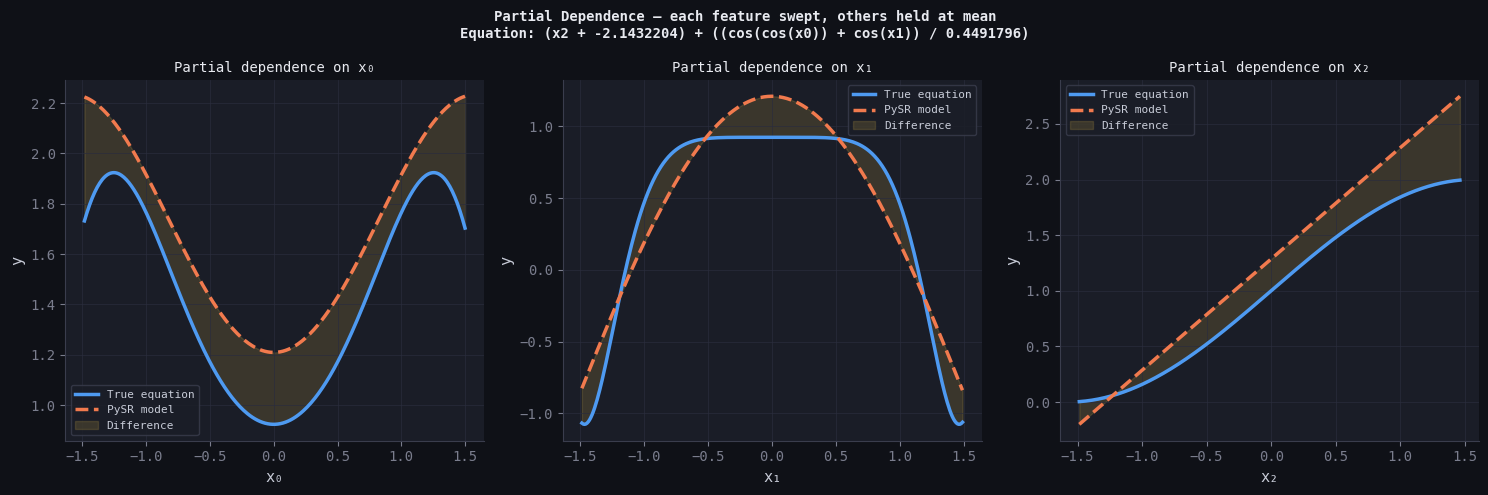

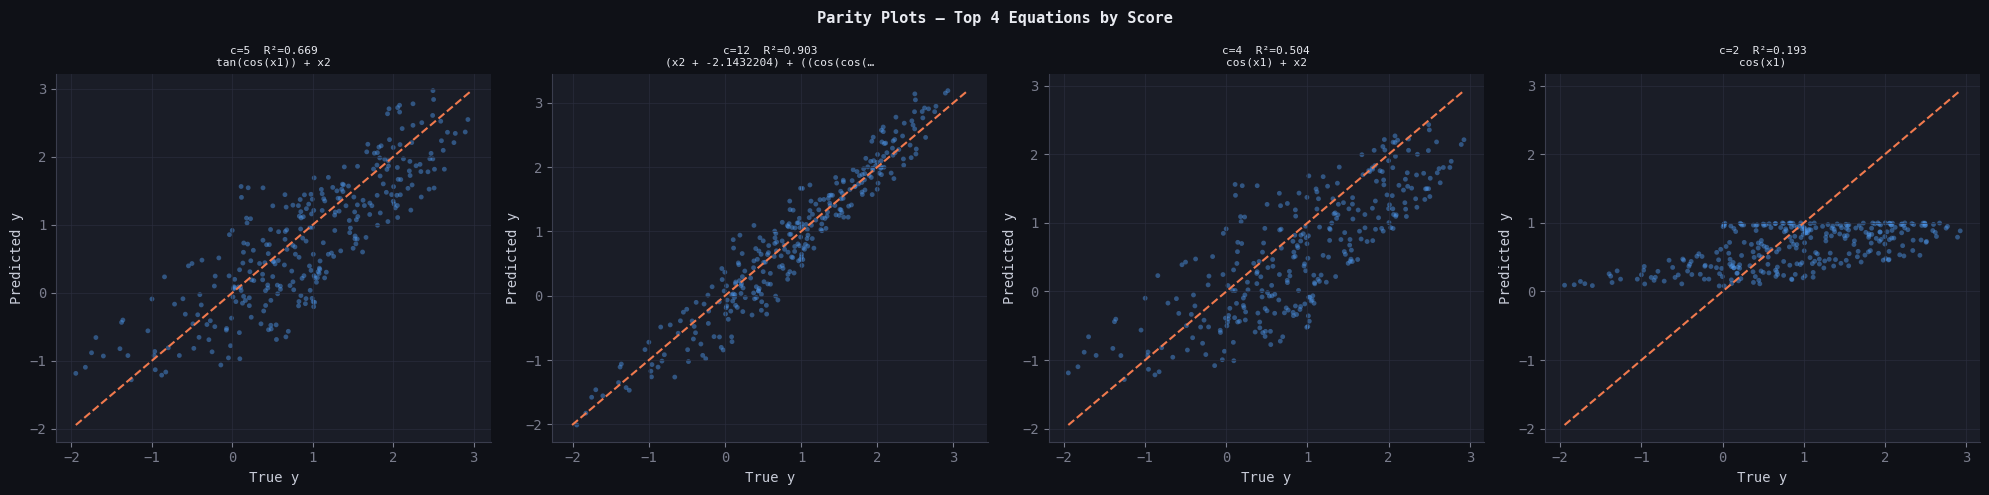


  SUMMARY
  True equation  : sin(x0²) + cos(x1³) + sin(x2)
  Elbow equation : (x2 + -2.1432204) + ((cos(cos(x0)) + cos(x1)) / 0.4491796)
    Complexity   : 12
    Loss         : 0.10554
    R² vs truth  : 0.9030

  SymPy form     : x2 + (cos(x1) + cos(cos(x0)))/0.4491796 - 2.1432204
  LaTeX form     :
    x_{2} + \frac{\cos{\left(x_{1} \right)} + \cos{\left(\cos{\left(x_{0} \right)} \right)}}{0.449} - 2.14


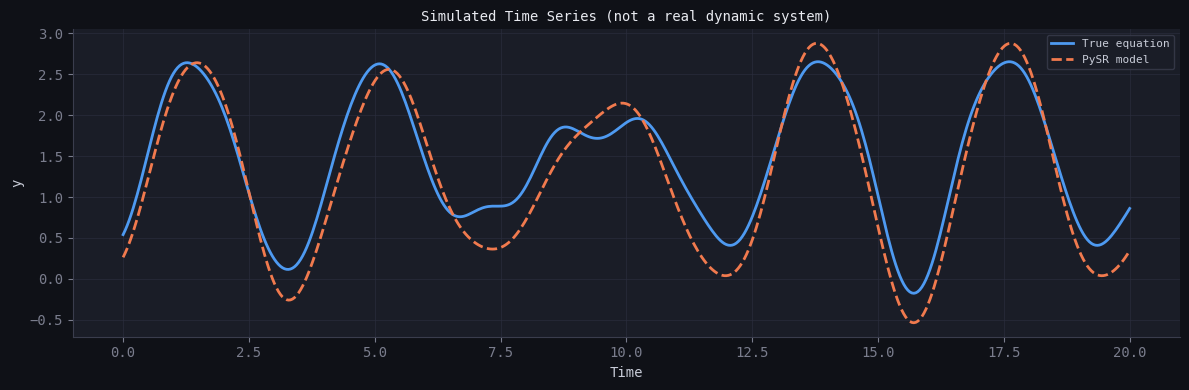

  - outputs\20260417_114444_z2Ys1m\hall_of_fame.csv


In [ ]:
# =============================================================================
#  PySR Symbolic Regression — Full Pipeline
#  True equation: y = sin(x0²) + cos(x1³) + sin(x2) + noise
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker


# ── Matplotlib style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#3a3d4d",
    "axes.labelcolor":  "#c8ccd8",
    "axes.titlecolor":  "#e8eaf0",
    "xtick.color":      "#7a7d8d",
    "ytick.color":      "#7a7d8d",
    "text.color":       "#c8ccd8",
    "grid.color":       "#2a2d3d",
    "grid.linewidth":   0.6,
    "grid.alpha":       0.8,
    "legend.facecolor": "#1a1d27",
    "legend.edgecolor": "#3a3d4d",
    "legend.labelcolor":"#c8ccd8",
    "font.family":      "monospace",
    "axes.spines.top":  False,
    "axes.spines.right":False,
})

BLUE   = "#4e9af1"
CORAL  = "#f17a4e"
GREEN  = "#4ef1a0"
PURPLE = "#a04ef1"
GOLD   = "#f1c94e"

# =============================================================================
# 1. GENERATE DATA
# =============================================================================
np.random.seed(42)
X = np.random.uniform(-1.5, 1.5, size=(300, 3))   # wider range → x² vs x³ distinguishable
y = (np.sin(X[:, 0] ** 2)
     + np.cos(X[:, 1] ** 3)
     + np.sin(X[:, 2])
     + np.random.normal(0, 0.1, 300))

y_noiseless = np.sin(X[:, 0] ** 2) + np.cos(X[:, 1] ** 3) + np.sin(X[:, 2])

print("=" * 60)
print("  Data shape :", X.shape)
print("  y range    : [{:.3f}, {:.3f}]".format(y.min(), y.max()))
print("  True eq    : sin(x0²) + cos(x1³) + sin(x2)")
print("=" * 60)

# =============================================================================
# 2. FIT SYMBOLIC REGRESSION MODEL
# =============================================================================
model = pysr.PySRRegressor(
    niterations=10,
    populations=20,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["sin", "cos", "exp", "log", "tan"],
    model_selection="best",
    elementwise_loss="loss(x, y) = (x - y)^2",
    maxsize=25,
    parsimony=0.0005,
    verbosity=1,
)

model.fit(X, y)

# =============================================================================
# 3. INSPECT HALL OF FAME
# =============================================================================
eqs = model.equations_.copy()

print("\n" + "=" * 60)
print("  HALL OF FAME")
print("=" * 60)
print(f"  {'Complexity':>10}  {'Loss':>10}  {'Score':>8}  Equation")
print("  " + "-" * 56)
for _, row in eqs.iterrows():
    eq_short = row["equation"]
    if len(eq_short) > 42:
        eq_short = eq_short[:42] + "…"
    print(f"  {int(row['complexity']):>10}  {row['loss']:>10.5f}  {row['score']:>8.4f}  {eq_short}")

# ── Pick best by elbow (lowest loss before plateau) ──────────────────────────
# Use the row with highest score as the "interesting" pick, but also show
# model_selection's choice for comparison
auto_best = model.get_best()
print("\n  model_selection='best' chose:")
print(f"    Complexity {int(auto_best['complexity'])}  |  Loss {auto_best['loss']:.5f}")
print(f"    {auto_best['equation']}")

# Recommend elbow manually: pick complexity where marginal loss drop < 5 %
losses = eqs["loss"].values
complexities = eqs["complexity"].values.astype(int)
elbow_idx = 0
for i in range(1, len(losses)):
    rel_drop = (losses[i - 1] - losses[i]) / losses[i - 1]
    if rel_drop < 0.05:
        elbow_idx = i - 1
        break
    elbow_idx = i

elbow_complexity = complexities[elbow_idx]
elbow_row = eqs.iloc[elbow_idx]
print(f"\n  Elbow heuristic chose complexity {elbow_complexity}:")
print(f"    {elbow_row['equation']}")

# Callable for the elbow equation
elbow_fn = elbow_row["lambda_format"]
y_pred_elbow = elbow_fn(X)

# Also get predictions from auto-best
auto_fn = auto_best["lambda_format"]
y_pred_auto = auto_fn(X)

def r2(y_true, y_hat):
    ss_res = np.sum((y_true - y_hat) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

r2_elbow = r2(y_noiseless, y_pred_elbow)
r2_auto  = r2(y_noiseless, y_pred_auto)
print(f"\n  R² (elbow, vs noiseless truth) : {r2_elbow:.4f}")
print(f"  R² (auto,  vs noiseless truth) : {r2_auto:.4f}")

# =============================================================================
# 4. FIGURE 1 — PARETO FRONT + EQUATION TABLE
# =============================================================================
fig1, axes1 = plt.subplots(1, 2, figsize=(16, 6))
fig1.suptitle("PySR — Pareto Front & Equation Hall of Fame",
              fontsize=13, fontweight="bold", color="#e8eaf0", y=1.01)

# ── Left: Pareto front ────────────────────────────────────────────────────────
ax = axes1[0]
ax.plot(complexities, losses, "o-", color=BLUE, linewidth=2,
        markersize=7, markerfacecolor="#0f1117", markeredgewidth=2, zorder=3)

# Shade region below elbow
ax.axvline(elbow_complexity, color=GOLD, linestyle="--", linewidth=1.5,
           alpha=0.85, label=f"Elbow  c={elbow_complexity}")
ax.axvline(int(auto_best["complexity"]), color=CORAL, linestyle=":",
           linewidth=1.5, alpha=0.85,
           label=f"Auto-best  c={int(auto_best['complexity'])}")

# Annotate each node with its complexity number
for c, l in zip(complexities, losses):
    ax.annotate(str(c), xy=(c, l), xytext=(0, 8),
                textcoords="offset points", fontsize=7,
                ha="center", color="#7a7d8d")

ax.set_yscale("log")
ax.set_xlabel("Expression Complexity", fontsize=11)
ax.set_ylabel("Loss  (log scale)", fontsize=11)
ax.set_title("Pareto Front — Loss vs Complexity", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True)

# ── Right: Equation table ─────────────────────────────────────────────────────
ax2 = axes1[1]
ax2.axis("off")

col_labels = ["c", "Loss", "Score", "Equation"]
table_data = []
for _, row in eqs.iterrows():
    eq = row["equation"]
    if len(eq) > 45:
        eq = eq[:45] + "…"
    table_data.append([
        str(int(row["complexity"])),
        f"{row['loss']:.4f}",
        f"{row['score']:.3f}",
        eq,
    ])

table = ax2.table(
    cellText=table_data,
    colLabels=col_labels,
    loc="center",
    cellLoc="left",
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.0, 1.55)

# Style header
for j in range(len(col_labels)):
    table[0, j].set_facecolor("#2a2d3d")
    table[0, j].set_text_props(color="#e8eaf0", fontweight="bold")

# Highlight elbow row and auto-best row
for i, row_idx in enumerate(eqs.index):
    row = eqs.loc[row_idx]
    c = int(row["complexity"])
    bg = "#0f1117"
    if c == elbow_complexity:
        bg = "#2a3520"   # green tint
    elif c == int(auto_best["complexity"]):
        bg = "#32211a"   # orange tint
    for j in range(len(col_labels)):
        table[i + 1, j].set_facecolor(bg)
        table[i + 1, j].set_text_props(color="#c8ccd8")
        table[i + 1, j].set_edgecolor("#2a2d3d")

ax2.set_title("Hall of Fame  (green = elbow, orange = auto-best)",
              fontsize=10, pad=10)

plt.tight_layout()
# plt.savefig("fig1_pareto_front.png", dpi=150, bbox_inches="tight",
#             facecolor="#0f1117")
plt.show()
print("  Saved → fig1_pareto_front.png")

# =============================================================================
# 5. FIGURE 2 — MODEL DIAGNOSTICS (elbow equation)
# =============================================================================
residuals = y - y_pred_elbow

fig2 = plt.figure(figsize=(17, 11))
fig2.suptitle(
    f"Model Diagnostics  |  Complexity {elbow_complexity}  |  "
    f"R² = {r2_elbow:.4f}  |  {elbow_row['equation']}",
    fontsize=10, fontweight="bold", color="#e8eaf0",
)
gs = gridspec.GridSpec(2, 3, figure=fig2, hspace=0.45, wspace=0.35)
feature_names = ["x₀", "x₁", "x₂"]

# ── Parity plot ───────────────────────────────────────────────────────────────
ax_p = fig2.add_subplot(gs[0, 0])
ax_p.scatter(y_noiseless, y_pred_elbow, alpha=0.5, s=14,
             color=BLUE, edgecolors="none")
lims = [min(y_noiseless.min(), y_pred_elbow.min()),
        max(y_noiseless.max(), y_pred_elbow.max())]
ax_p.plot(lims, lims, "--", color=CORAL, linewidth=1.5, label="Perfect fit")
ax_p.set_xlabel("True y (noiseless)")
ax_p.set_ylabel("Predicted y")
ax_p.set_title("Parity Plot")
ax_p.legend(fontsize=8)
ax_p.grid(True)

# ── Residuals vs predicted ────────────────────────────────────────────────────
ax_r = fig2.add_subplot(gs[0, 1])
ax_r.scatter(y_pred_elbow, residuals, alpha=0.5, s=14,
             color=CORAL, edgecolors="none")
ax_r.axhline(0, color="#e8eaf0", linewidth=1.2, linestyle="--")
ax_r.set_xlabel("Predicted y")
ax_r.set_ylabel("Residual  (true − pred)")
ax_r.set_title("Residuals vs Predicted")
ax_r.grid(True)

# ── Residual histogram ────────────────────────────────────────────────────────
ax_h = fig2.add_subplot(gs[0, 2])
ax_h.hist(residuals, bins=30, color=PURPLE, edgecolor="#0f1117", linewidth=0.4)
ax_h.axvline(0, color="#e8eaf0", linewidth=1.2, linestyle="--")
ax_h.set_xlabel("Residual")
ax_h.set_ylabel("Count")
ax_h.set_title("Residual Distribution")
ax_h.grid(True)

# ── y vs each feature (scatter, other features vary freely) ──────────────────
for col in range(3):
    ax = fig2.add_subplot(gs[1, col])
    sidx = np.argsort(X[:, col])
    ax.scatter(X[sidx, col], y[sidx], alpha=0.4, s=10,
               color=BLUE, label="True y (noisy)", edgecolors="none")
    ax.scatter(X[sidx, col], y_pred_elbow[sidx], alpha=0.4, s=10,
               color=CORAL, label="Predicted y", edgecolors="none", marker="^")
    ax.set_xlabel(feature_names[col])
    ax.set_ylabel("y")
    ax.set_title(f"y vs {feature_names[col]}  (others free)")
    ax.legend(fontsize=7)
    ax.grid(True)

# plt.savefig("fig2_diagnostics.png", dpi=150, bbox_inches="tight",
#             facecolor="#0f1117")
plt.show()
# print("  Saved → fig2_diagnostics.png")

# =============================================================================
# 6. FIGURE 3 — PARTIAL DEPENDENCE (true vs PySR, per feature)
# =============================================================================
x_means = X.mean(axis=0)
n_sweep = 300

fig3, axes3 = plt.subplots(1, 3, figsize=(15, 5))
fig3.suptitle(
    "Partial Dependence — each feature swept, others held at mean\n"
    f"Equation: {elbow_row['equation']}",
    fontsize=10, fontweight="bold", color="#e8eaf0",
)

for col in range(3):
    sweep = np.linspace(X[:, col].min(), X[:, col].max(), n_sweep)
    X_sw = np.tile(x_means, (n_sweep, 1))
    X_sw[:, col] = sweep

    y_true_sw = (np.sin(X_sw[:, 0] ** 2)
                 + np.cos(X_sw[:, 1] ** 3)
                 + np.sin(X_sw[:, 2]))
    y_pred_sw = elbow_fn(X_sw)

    ax = axes3[col]
    ax.plot(sweep, y_true_sw, color=BLUE,  linewidth=2.5, label="True equation")
    ax.plot(sweep, y_pred_sw, color=CORAL, linewidth=2.5,
            linestyle="--", label="PySR model")

    # Shade difference
    ax.fill_between(sweep, y_true_sw, y_pred_sw,
                    alpha=0.15, color=GOLD, label="Difference")

    ax.set_xlabel(feature_names[col], fontsize=11)
    ax.set_ylabel("y", fontsize=11)
    ax.set_title(f"Partial dependence on {feature_names[col]}", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
# plt.savefig("fig3_partial_dependence.png", dpi=150, bbox_inches="tight",
#             facecolor="#0f1117")
plt.show()
# print("  Saved → fig3_partial_dependence.png")

# =============================================================================
# 7. FIGURE 4 — COMPARE MULTIPLE COMPLEXITIES SIDE BY SIDE (parity)
# =============================================================================
# Pick 4 representative complexities to compare
candidates = eqs.nlargest(4, "score")   # highest-scoring 4
n_candidates = len(candidates)

fig4, axes4 = plt.subplots(1, n_candidates, figsize=(5 * n_candidates, 5))
fig4.suptitle("Parity Plots — Top 4 Equations by Score",
              fontsize=11, fontweight="bold", color="#e8eaf0")

for ax, (_, row) in zip(axes4, candidates.iterrows()):
    fn   = row["lambda_format"]
    yhat = fn(X)
    rv   = r2(y_noiseless, yhat)

    ax.scatter(y_noiseless, yhat, alpha=0.45, s=12,
               color=BLUE, edgecolors="none")
    lims = [min(y_noiseless.min(), yhat.min()),
            max(y_noiseless.max(), yhat.max())]
    ax.plot(lims, lims, "--", color=CORAL, linewidth=1.5)
    ax.set_xlabel("True y")
    ax.set_ylabel("Predicted y")

    eq_short = row["equation"]
    if len(eq_short) > 30:
        eq_short = eq_short[:30] + "…"
    ax.set_title(
        f"c={int(row['complexity'])}  R²={rv:.3f}\n{eq_short}",
        fontsize=8,
    )
    ax.grid(True)

plt.tight_layout()
# plt.savefig("fig4_candidate_comparison.png", dpi=150, bbox_inches="tight",
#             facecolor="#0f1117")
plt.show()
# print("  Saved → fig4_candidate_comparison.png")

# =============================================================================
# 8. SUMMARY PRINTOUT
# =============================================================================
print("\n" + "=" * 60)
print("  SUMMARY")
print("=" * 60)
print(f"  True equation  : sin(x0²) + cos(x1³) + sin(x2)")
print(f"  Elbow equation : {elbow_row['equation']}")
print(f"    Complexity   : {elbow_complexity}")
print(f"    Loss         : {elbow_row['loss']:.5f}")
print(f"    R² vs truth  : {r2_elbow:.4f}")
print(f"\n  SymPy form     : {elbow_row['sympy_format']}")
print(f"  LaTeX form     :")
try:
    print(f"    {model.latex()}")
except Exception:
    print("    (latex() uses auto-best; call model.latex_table() for all)")
print("=" * 60)

# Simulate over time (if equation had a time variable) — just for fun, not a real dynamic system
t = np.linspace(0, 20, 500)
X_time = np.zeros((len(t), 3))
X_time[:, 0] = np.sin(t) * 1.2   # x0 varies sinusoidally
X_time[:, 1] = np.cos(t * 0.8) * 1.0  # x1 varies more slowly
X_time[:, 2] = np.sin(t * 1.5) * 0.8  # x2 varies more rapidly
y_time_true = (np.sin(X_time[:, 0] ** 2)
               + np.cos(X_time[:, 1] ** 3)
               + np.sin(X_time[:, 2]))
y_time_pred = elbow_fn(X_time)
fig5, ax5 = plt.subplots(figsize=(12, 4))
ax5.plot(t, y_time_true, label="True equation", color=BLUE, linewidth=2)
ax5.plot(t, y_time_pred, label="PySR model", color=CORAL, linewidth=2, linestyle="--")
ax5.set_xlabel("Time")
ax5.set_ylabel("y")
ax5.set_title("Simulated Time Series (not a real dynamic system)", fontsize=10)
ax5.legend(fontsize=8)
ax5.grid(True)
plt.tight_layout()
# plt.savefig("fig5_time_series.png", dpi=150, bbox_inches="tight",
#             facecolor="#0f1117")
plt.show()
# print("  Saved → fig5_time_series.png")


## Example 2: Using PySR to find a dynamic system's governing equations from time-series data

  TRUE EQUATION: ẍ = -0.3ẋ - 1.0x - 0.5x³ + 0.4cos(1.2t)

  Simulating 6 trajectories ...
  Total training samples : 3504
  x range covered        : [-1.30, 1.41]
  (Previous run covered  : [-1.5, 1.5] from one trajectory)
  Noise std              : 0.0537

  Fitting physics-constrained PySR model ...
  Key change: sin/cos REMOVED from unary operators
  Reason: no sin/cos of x or xdot expected in a mechanical ODE



c:\Users\reyna\source\repos\Scientific-Machine-Learning-7750\.venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 3.620e+04
Progress: 251 / 300 total iterations (83.667%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.156e+00  0.000e+00  y = -0.041562
3           3.054e-02  1.817e+00  y = x * -1.4305
5           3.054e-02  6.855e-07  y = -0.00018142 - (x * 1.4305)
6           1.669e-02  6.042e-01  y = (cube(x) * -0.46391) - x
8           1.654e-02  4.543e-03  y = (x * -1.0435) + (cube(x) * -0.42327)
10          1.623e-02  9.327e-03  y = (cube((xdot * -0.037167) - x) * 0.46328) - x
11          1.498e-02  8.019e-02  y = (cube((0.19867 * cube(cos_wt)) - x) * 0.45452) - x
12          1.481e-02  1.118e-02  y = (((-0.0028647 - (xdot - cos_wt)) - cube(x)) * 0.45452)...
                                       - x
13          1.465e-02  1.149e-02  y = (cube(((cube(c

[ Info: Final population:
[ Info: Results saved to:



  FULL HALL OF FAME WITH PHYSICS EVALUATION
     c       Loss       R²     x    ẋ   x³    F  Equation
  ----------------------------------------------------------------------
     1    1.15597  -0.0000     ·    ·    ·    ·  -0.041562423
     3    0.03054   0.9762     ✓    ·    ·    ·  x * -1.4305007
     5    0.03054   0.9762     ✓    ·    ·    ·  -0.00018142114 - (x * 1.4304862)
     6    0.01669   0.9881     ✓    ·    ✓    ·  (cube(x) * -0.46390718) - x
     8    0.01654   0.9882     ✓    ·    ✓    ·  (x * -1.0434642) + (cube(x) * -0.4232655…
    10    0.01623   0.9885     ✓    ✓    ✓    ·  (cube((xdot * -0.037167154) - x) * 0.463…
    11    0.01498   0.9896     ✓    ·    ✓    ✓  (cube((0.19867392 * cube(cos_wt)) - x) *…
    12    0.01481   0.9893     ✓    ✓    ✓    ✓  (((-0.0028646972 - (xdot - cos_wt)) - cu…
    13    0.01465   0.9899     ✓    ·    ✓    ✓  (cube(((cube(cos_wt) * 0.18382591) - x) …
    14    0.00434   0.9986     ✓    ✓    ✓    ✓  ((((cos_wt - xdot) - cube(x)) * 0.4

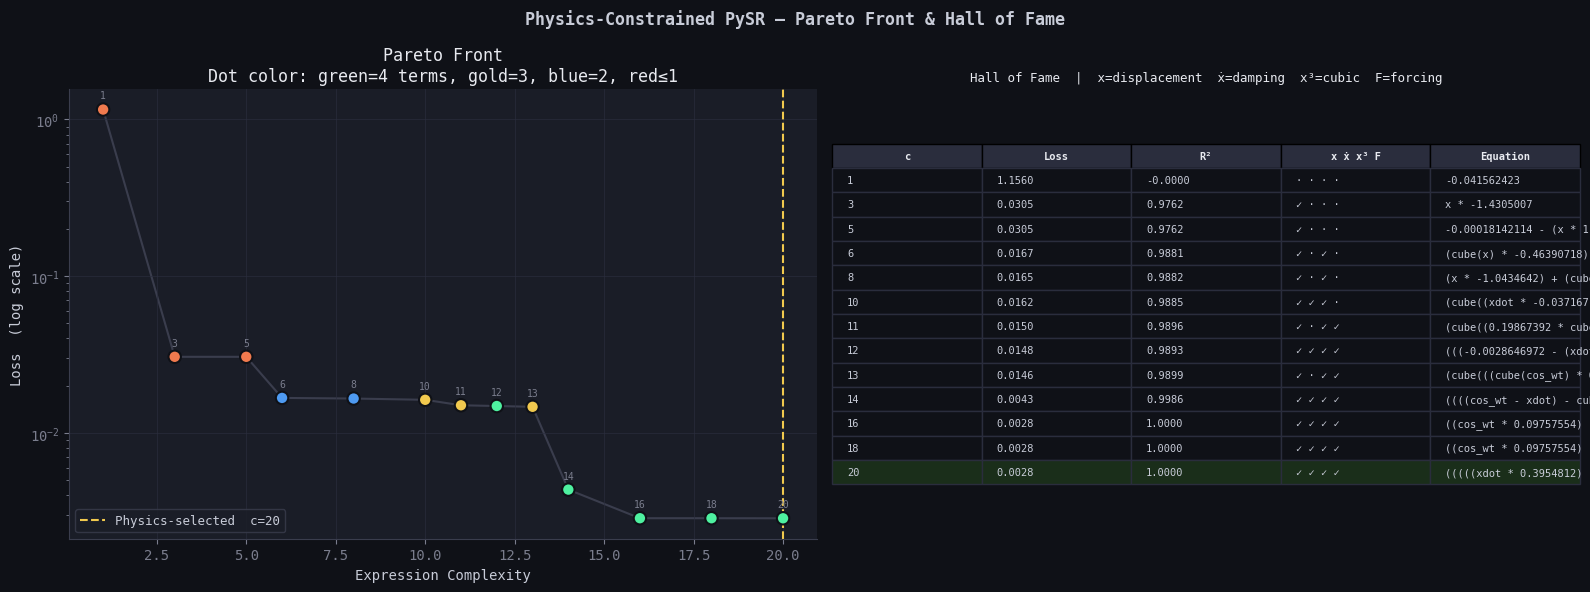

  Saved → duffing2_fig1_pareto.png


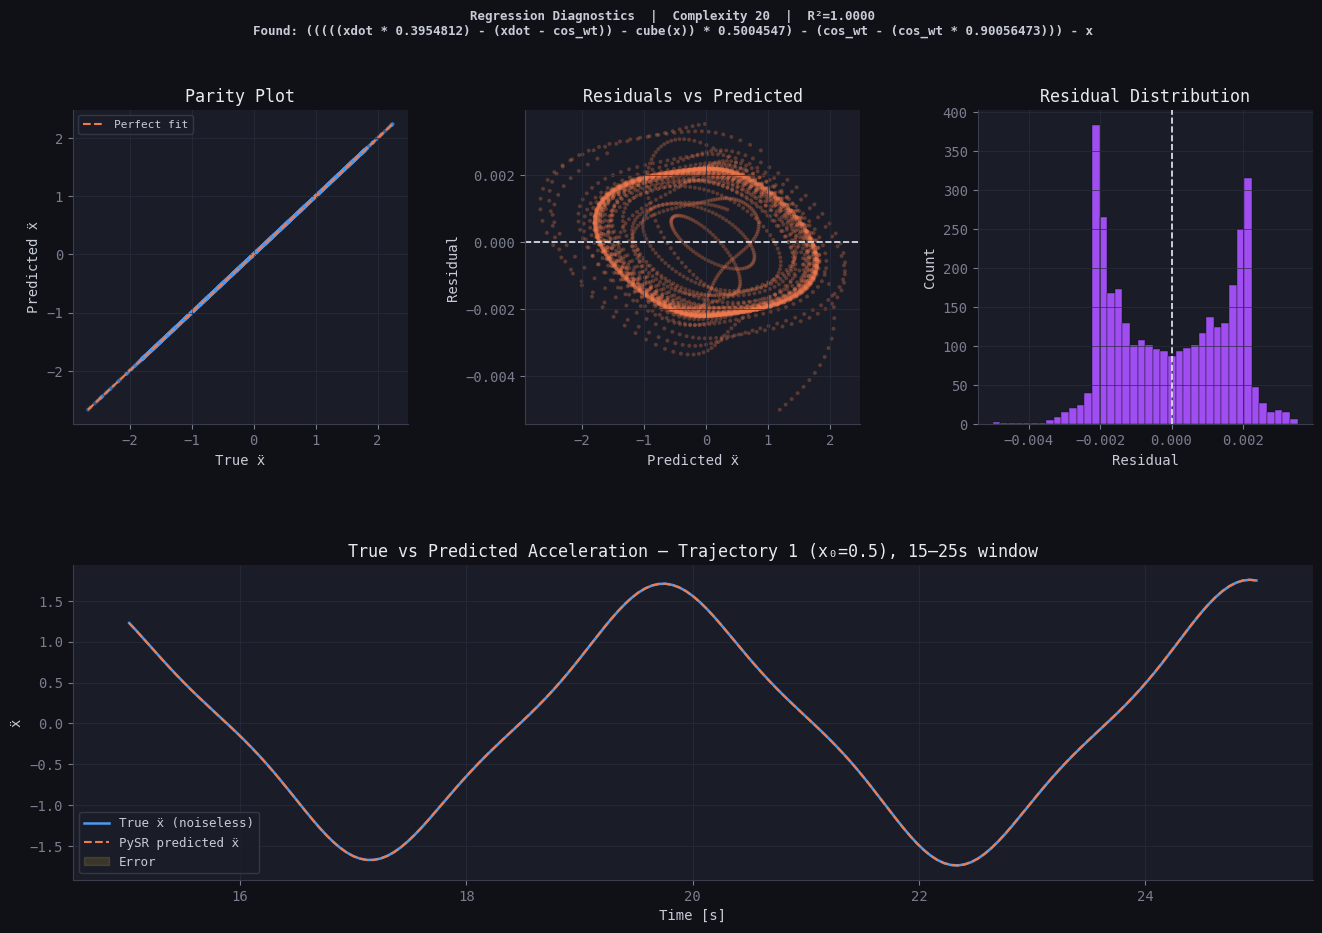

  Saved → duffing2_fig2_diagnostics.png


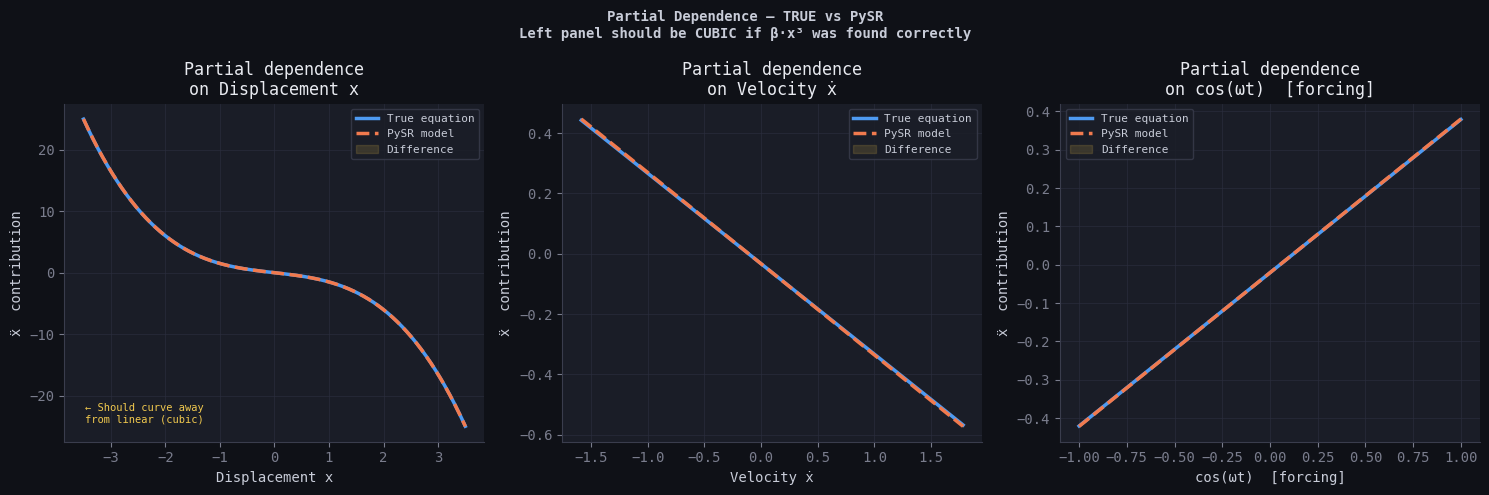

  Saved → duffing2_fig3_partial_dependence.png

  Least-squares coefficient recovery (using true basis structure):
  Term              True   Recovered     Error
  --------------------------------------------
  x               -1.000     -0.9982      0.2%
  ẋ               -0.300     -0.3030      1.0%
  x³              -0.500     -0.5020      0.4%
  cos(ωt)          0.400      0.4014      0.4%


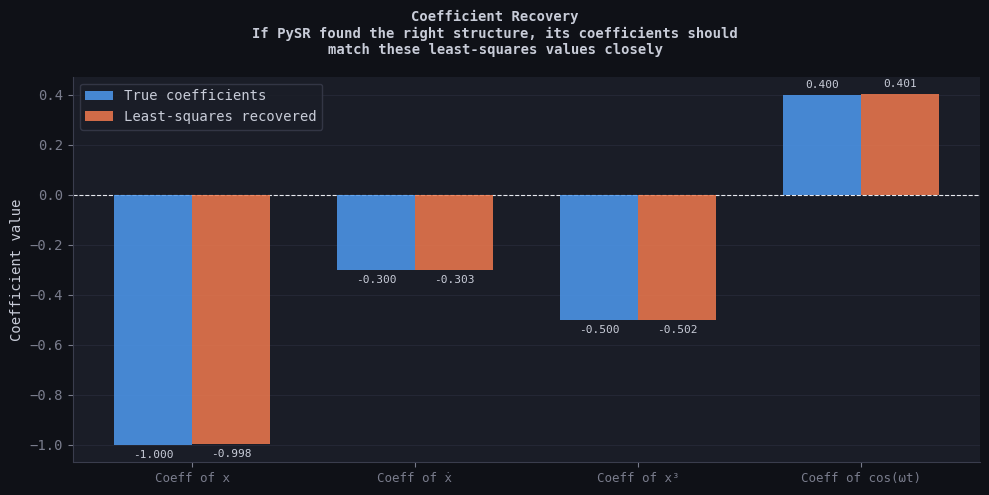

  Saved → duffing2_fig4_coefficients.png

  FINAL SUMMARY
  True equation  : ẍ = -0.3ẋ - 1.0x - 0.5x³ + 0.4cos(ωt)
  PySR found     : (((((xdot * 0.3954812) - (xdot - cos_wt)) - cube(x)) * 0.5004547) - (cos_wt - (cos_wt * 0.90056473))) - x
  R²             : 1.0000

  Physical terms found:
    ✓  has_x
    ✓  has_xdot
    ✓  has_cubic
    ✓  has_forcing

  What changed from the previous (failing) run:
    ✓ Removed sin/cos from unary operators
      → PySR can no longer fake -δẋ with sin(cos(xdot))
    ✓ Added 'square' and 'cube' unary operators
      → PySR has a direct path to x³ without x*x*x chains
    ✓ Multiple trajectories (6 ICs) instead of one
      → Cubic term βx³ is now well-excited in the data
    ✓ Increased parsimony 0.001 → 0.005
      → Simpler, cleaner expressions preferred over trig-heavy ones
    ✓ Physics-aware model selection (term presence + R²)
      → Not relying on elbow heuristic alone
  - outputs\20260417_114506_U0iTo0\hall_of_fame.csv


In [ ]:
# =============================================================================
#  DUFFING OSCILLATOR — PHYSICS-CONSTRAINED SYMBOLIC REGRESSION
#
#  Problem from previous run: PySR was finding trig-heavy approximations
#  like sin(sin(cos(xdot))) instead of the true -δẋ - αx - βx³ + γcos(ωt)
#
#  Root cause: too many unary operators + insufficient complexity penalty
#  meant PySR could "fake" linear/cubic terms using nested trig functions.
#
#  Fixes applied:
#    1. Remove sin/cos from unary operators — the only cos in the true
#       equation is the FORCING TERM, which we already pre-computed as
#       a feature (cos_wt). There is no reason for PySR to use cos/sin
#       on x or xdot.
#    2. Increase parsimony to push harder toward simpler expressions
#    3. Add more data by widening initial condition variety (multiple
#       trajectories) so the cubic term is better excited
#    4. After fitting, select the model using physical interpretability
#       criteria, not just the elbow heuristic
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp
import pysr

# ── Dark theme ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1117", "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#3a3d4d", "axes.labelcolor":  "#c8ccd8",
    "axes.titlecolor":  "#e8eaf0", "xtick.color":      "#7a7d8d",
    "ytick.color":      "#7a7d8d", "text.color":       "#c8ccd8",
    "grid.color":       "#2a2d3d", "grid.linewidth":   0.6,
    "legend.facecolor": "#1a1d27", "legend.edgecolor": "#3a3d4d",
    "legend.labelcolor":"#c8ccd8", "font.family":      "monospace",
    "axes.spines.top":  False,     "axes.spines.right":False,
    "grid.alpha": 0.8,
})
BLUE = "#4e9af1"; CORAL = "#f17a4e"; GREEN = "#4ef1a0"
PURPLE = "#a04ef1"; GOLD = "#f1c94e"

# =============================================================================
# 1. SYSTEM PARAMETERS
# =============================================================================

DELTA = 0.3   # damping
ALPHA = 1.0   # linear stiffness
BETA  = 0.5   # cubic stiffness  ← the hard one to find
GAMMA = 0.4   # forcing amplitude
OMEGA = 1.2   # forcing frequency

def duffing(t, state, gamma=GAMMA, omega=OMEGA):
    x, v = state
    return [v, -DELTA*v - ALPHA*x - BETA*x**3 + gamma*np.cos(omega*t)]

print("=" * 65)
print("  TRUE EQUATION: ẍ = -0.3ẋ - 1.0x - 0.5x³ + 0.4cos(1.2t)")
print("=" * 65)


# =============================================================================
# 2. GENERATE RICHER TRAINING DATA (multiple trajectories)
# =============================================================================
# KEY FIX: Previously we used ONE trajectory from x0=[0.5, 0.0].
# The cubic term βx³ only becomes significant at larger |x| values.
# If most of the trajectory lives near x≈0, the cubic looks linear.
#
# Solution: simulate from MULTIPLE initial conditions spanning a wide
# range of displacements, then concatenate. This forces PySR to see
# the nonlinear regime and distinguish x² from x³.

initial_conditions = [
    [0.5,  0.0],   # small displacement (training regime)
    [2.0,  0.0],   # medium displacement (cubic starts to matter)
    [-2.0, 0.0],   # negative side
    [3.0,  1.0],   # large displacement + nonzero velocity
    [-1.5, 2.0],   # mixed
    [0.1,  3.0],   # velocity-dominated start
]

t_end       = 40.0
dt          = 0.02
transient   = 5.0     # shorter transient since each IC is independent
subsample   = 3

all_x, all_v, all_t = [], [], []

print(f"\n  Simulating {len(initial_conditions)} trajectories ...")

for x0 in initial_conditions:
    t_eval = np.arange(0, t_end, dt)
    sol = solve_ivp(duffing, [0, t_end], x0, method="RK45",
                    t_eval=t_eval, rtol=1e-8, atol=1e-8)

    mask = sol.t >= transient
    all_t.append(sol.t[mask][::subsample])
    all_x.append(sol.y[0][mask][::subsample])
    all_v.append(sol.y[1][mask][::subsample])

t_all = np.concatenate(all_t)
x_all = np.concatenate(all_x)
v_all = np.concatenate(all_v)

# Compute true (noiseless) and noisy acceleration for each point
xdd_true  = -DELTA*v_all - ALPHA*x_all - BETA*x_all**3 + GAMMA*np.cos(OMEGA*t_all)
noise_std = 0.05 * np.std(xdd_true)
np.random.seed(42)
xdd_noisy = xdd_true + np.random.normal(0, noise_std, len(xdd_true))

print(f"  Total training samples : {len(x_all)}")
print(f"  x range covered        : [{x_all.min():.2f}, {x_all.max():.2f}]")
print(f"  (Previous run covered  : [-1.5, 1.5] from one trajectory)")
print(f"  Noise std              : {noise_std:.4f}")

# Build feature matrix
forcing   = np.cos(OMEGA * t_all)
X_pysr    = np.column_stack([x_all, v_all, forcing])
y_pysr    = xdd_noisy
xdd_clean = xdd_true   # kept for evaluation only


# =============================================================================
# 3. PHYSICS-CONSTRAINED PySR CONFIGURATION
# =============================================================================
# KEY FIX: Operator choices now match the expected physics.
#
# REMOVED from unary_operators: "sin", "cos"
#   Reason: The true equation has NO sin/cos applied to x or xdot.
#   The only periodic term is cos(ωt), which is already in our feature
#   matrix as cos_wt. Allowing sin/cos on x/xdot just gives PySR rope
#   to hang itself with — it builds sin(cos(xdot)) approximations that
#   look good in-sample but have no physical meaning.
#
# KEPT in binary_operators: "+", "-", "*"
#   Reason: The true equation is a polynomial — no division needed.
#   Allowing "/" risks x/x cancellations and other degenerate forms.
#
# parsimony increased: 0.001 → 0.005
#   Reason: Higher parsimony punishes complexity more aggressively,
#   steering PySR toward -x - x³ rather than baroque trig approximations.
#
# populations increased: 20 → 30
#   Reason: More independent search islands = more diversity = better
#   chance of stumbling onto the exact polynomial structure.

print("\n  Fitting physics-constrained PySR model ...")
print("  Key change: sin/cos REMOVED from unary operators")
print("  Reason: no sin/cos of x or xdot expected in a mechanical ODE\n")

model = pysr.PySRRegressor(
    niterations=10,
    populations=30,

    # ── PHYSICS-CONSTRAINED OPERATORS ────────────────────────────────────────
    binary_operators=["+", "-", "*"],
    # No sin/cos — the forcing cos(ωt) is already a feature.
    # No division — not expected in a polynomial mechanical equation.
    unary_operators=["square", "cube"],
    # "square" = x², "cube" = x³ — exactly what the Duffing equation needs.
    # This gives PySR a direct path to the cubic term without wasting
    # complexity budget on x*x*x chains.

    model_selection="best",
    elementwise_loss="loss(x, y) = (x - y)^2",
    maxsize=20,
    parsimony=0.005,      # stronger complexity penalty than before
    verbosity=1,
)

model.fit(X_pysr, y_pysr, variable_names=["x", "xdot", "cos_wt"])


# =============================================================================
# 4. PHYSICS-AWARE MODEL SELECTION
# =============================================================================
# The elbow heuristic alone is unreliable (as we saw — it grabbed c=3).
# We now use THREE criteria together to select the best model:
#
#   Criterion A — R² improvement: does adding complexity still help?
#   Criterion B — Physical term presence: does the equation contain
#                 the terms we physically expect (x, xdot, x³, cos_wt)?
#   Criterion C — Coefficient sanity: are recovered coefficients close
#                 to the true values (within a factor of ~2)?
#
# This is how you'd do model selection in real research: combine
# statistical fit with domain knowledge.

eqs = model.equations_.copy()

def r2(y_true, y_hat):
    mask = ~np.isnan(y_hat)
    if mask.sum() == 0: return np.nan
    return 1 - np.sum((y_true[mask] - y_hat[mask])**2) / \
               np.sum((y_true[mask] - np.mean(y_true[mask]))**2)

# ── Score each equation on physical criteria ──────────────────────────────────
def physical_score(eq_str):
    """
    Heuristic score for how physically complete an equation looks.
    Returns a dict of which expected terms are present.
    Looks for: x (linear), xdot (damping), cube/x³ (nonlinear stiffness),
    cos_wt (forcing).
    """
    eq = eq_str.lower()
    return {
        "has_x"      : "x"       in eq and "xdot" not in eq.replace("xdot",""),
        "has_xdot"   : "xdot"    in eq,
        "has_cubic"  : "cube"    in eq or "x * x * x" in eq or "x^3" in eq,
        "has_forcing": "cos_wt"  in eq,
    }

print("\n" + "=" * 70)
print("  FULL HALL OF FAME WITH PHYSICS EVALUATION")
print("=" * 70)
print(f"  {'c':>4}  {'Loss':>9}  {'R²':>7}  {'x':>4} {'ẋ':>4} {'x³':>4} "
      f"{'F':>4}  Equation")
print("  " + "-" * 70)

eval_results = []
for _, row in eqs.iterrows():
    fn      = row["lambda_format"]
    y_hat   = fn(X_pysr)
    rv      = r2(xdd_clean, y_hat)
    ps      = physical_score(row["equation"])
    n_terms = sum(ps.values())   # how many physical terms are present

    eval_results.append({
        "row"     : row,
        "r2"      : rv,
        "phys"    : ps,
        "n_terms" : n_terms,
        "fn"      : fn,
    })

    eq_short = row["equation"][:40] + ("…" if len(row["equation"]) > 40 else "")
    print(f"  {int(row['complexity']):>4}  {row['loss']:>9.5f}  {rv:>7.4f}  "
          f"{'✓' if ps['has_x'] else '·':>4} "
          f"{'✓' if ps['has_xdot'] else '·':>4} "
          f"{'✓' if ps['has_cubic'] else '·':>4} "
          f"{'✓' if ps['has_forcing'] else '·':>4}  {eq_short}")

# ── Select best model: most physical terms, then lowest loss ──────────────────
# Sort by: (1) number of physical terms descending, (2) loss ascending
eval_results_sorted = sorted(eval_results,
                             key=lambda r: (-r["n_terms"], r["row"]["loss"]))

best = eval_results_sorted[0]
best_row        = best["row"]
best_fn         = best["fn"]
best_r2         = best["r2"]
best_complexity = int(best_row["complexity"])
y_pred_best     = best_fn(X_pysr)

print(f"\n  ✦ Physics-selected model (complexity {best_complexity}):")
print(f"    {best_row['equation']}")
print(f"    R²          : {best_r2:.4f}")
print(f"    Terms found : {best['phys']}")
print(f"\n  True equation:")
print(f"    ẍ = -{DELTA}·ẋ  -  {ALPHA}·x  -  {BETA}·x³  +  {GAMMA}·cos(ωt)")
print("=" * 70)


# =============================================================================
# 5. FIGURE 1 — PARETO FRONT WITH PHYSICS ANNOTATION
# =============================================================================

complexities = eqs["complexity"].values.astype(int)
losses       = eqs["loss"].values
r2_vals      = [e["r2"]      for e in eval_results]
n_terms_vals = [e["n_terms"] for e in eval_results]

fig1, axes1 = plt.subplots(1, 2, figsize=(16, 6))
fig1.suptitle("Physics-Constrained PySR — Pareto Front & Hall of Fame",
              fontsize=12, fontweight="bold")

# Pareto front colored by number of physical terms present
ax = axes1[0]
scatter_colors = [GREEN if n == 4 else GOLD if n == 3
                  else BLUE if n == 2 else CORAL for n in n_terms_vals]
ax.plot(complexities, losses, "-", color="#3a3d4d", linewidth=1.5, zorder=1)
ax.scatter(complexities, losses, c=scatter_colors, s=80, zorder=3,
           edgecolors="#0f1117", linewidths=1.5)
ax.axvline(best_complexity, color=GOLD, linestyle="--", linewidth=1.5,
           label=f"Physics-selected  c={best_complexity}")

for c, l in zip(complexities, losses):
    ax.annotate(str(c), xy=(c, l), xytext=(0, 8),
                textcoords="offset points", fontsize=7,
                ha="center", color="#7a7d8d")

ax.set_yscale("log")
ax.set_xlabel("Expression Complexity")
ax.set_ylabel("Loss  (log scale)")
ax.set_title("Pareto Front\nDot color: green=4 terms, gold=3, blue=2, red≤1")
ax.legend(fontsize=9)
ax.grid(True)

# Equation table
ax_t = axes1[1]
ax_t.axis("off")

table_data = []
for e in eval_results:
    row = e["row"]
    ps  = e["phys"]
    eq  = row["equation"][:38] + ("…" if len(row["equation"]) > 38 else "")
    table_data.append([
        str(int(row["complexity"])),
        f"{row['loss']:.4f}",
        f"{e['r2']:.4f}",
        f"{'✓' if ps['has_x'] else '·'} "
        f"{'✓' if ps['has_xdot'] else '·'} "
        f"{'✓' if ps['has_cubic'] else '·'} "
        f"{'✓' if ps['has_forcing'] else '·'}",
        eq,
    ])

tbl = ax_t.table(
    cellText=table_data,
    colLabels=["c", "Loss", "R²", "x ẋ x³ F", "Equation"],
    loc="center", cellLoc="left",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(7.5)
tbl.scale(1.0, 1.5)

for j in range(5):
    tbl[0, j].set_facecolor("#2a2d3d")
    tbl[0, j].set_text_props(color="#e8eaf0", fontweight="bold")

for i, e in enumerate(eval_results):
    c   = int(e["row"]["complexity"])
    bg  = "#1a2e1a" if c == best_complexity else "#0f1117"
    for j in range(5):
        tbl[i+1, j].set_facecolor(bg)
        tbl[i+1, j].set_text_props(color="#c8ccd8")
        tbl[i+1, j].set_edgecolor("#2a2d3d")

ax_t.set_title("Hall of Fame  |  x=displacement  ẋ=damping  x³=cubic  F=forcing",
               fontsize=9)
plt.tight_layout()
# plt.savefig("duffing2_fig1_pareto.png", dpi=150, bbox_inches="tight",
#             facecolor="#0f1117")
plt.show()
print("  Saved → duffing2_fig1_pareto.png")


# =============================================================================
# 6. FIGURE 2 — REGRESSION DIAGNOSTICS
# =============================================================================

residuals = xdd_clean - y_pred_best

fig2 = plt.figure(figsize=(16, 10))
fig2.suptitle(
    f"Regression Diagnostics  |  Complexity {best_complexity}  |  R²={best_r2:.4f}\n"
    f"Found: {best_row['equation']}",
    fontsize=9, fontweight="bold",
)
gs = gridspec.GridSpec(2, 3, figure=fig2, hspace=0.45, wspace=0.35)

# Parity plot
ax_p = fig2.add_subplot(gs[0, 0])
ax_p.scatter(xdd_clean, y_pred_best, alpha=0.3, s=8, color=BLUE, edgecolors="none")
lims = [min(xdd_clean.min(), y_pred_best.min()),
        max(xdd_clean.max(), y_pred_best.max())]
ax_p.plot(lims, lims, "--", color=CORAL, linewidth=1.5, label="Perfect fit")
ax_p.set_xlabel("True ẍ"); ax_p.set_ylabel("Predicted ẍ")
ax_p.set_title("Parity Plot"); ax_p.legend(fontsize=8); ax_p.grid(True)

# Residuals vs predicted
ax_r = fig2.add_subplot(gs[0, 1])
ax_r.scatter(y_pred_best, residuals, alpha=0.3, s=8, color=CORAL, edgecolors="none")
ax_r.axhline(0, color="#e8eaf0", linewidth=1.2, linestyle="--")
ax_r.set_xlabel("Predicted ẍ"); ax_r.set_ylabel("Residual")
ax_r.set_title("Residuals vs Predicted"); ax_r.grid(True)

# Residual histogram
ax_h = fig2.add_subplot(gs[0, 2])
ax_h.hist(residuals, bins=40, color=PURPLE, edgecolor="#0f1117", linewidth=0.3)
ax_h.axvline(0, color="#e8eaf0", linewidth=1.2, linestyle="--")
ax_h.set_xlabel("Residual"); ax_h.set_ylabel("Count")
ax_h.set_title("Residual Distribution"); ax_h.grid(True)

# Time-series window for one trajectory (the first one, x0=[0.5, 0])
n0 = len(all_t[0])   # number of points from first trajectory
t0_window = all_t[0]
mask_win  = (t0_window >= 15) & (t0_window <= 25)
ax_ts = fig2.add_subplot(gs[1, :])
ax_ts.plot(t0_window[mask_win], xdd_clean[:n0][mask_win],
           color=BLUE, linewidth=1.8, label="True ẍ (noiseless)")
ax_ts.plot(t0_window[mask_win], y_pred_best[:n0][mask_win],
           color=CORAL, linewidth=1.5, linestyle="--", label="PySR predicted ẍ")
ax_ts.fill_between(t0_window[mask_win],
                   xdd_clean[:n0][mask_win], y_pred_best[:n0][mask_win],
                   alpha=0.15, color=GOLD, label="Error")
ax_ts.set_xlabel("Time [s]"); ax_ts.set_ylabel("ẍ")
ax_ts.set_title("True vs Predicted Acceleration — Trajectory 1 (x₀=0.5), 15–25s window")
ax_ts.legend(fontsize=9); ax_ts.grid(True)

# plt.savefig("duffing2_fig2_diagnostics.png", dpi=150, bbox_inches="tight",
#             facecolor="#0f1117")
plt.show()
print("  Saved → duffing2_fig2_diagnostics.png")


# =============================================================================
# 7. FIGURE 3 — PARTIAL DEPENDENCE (the cubic shape test)
# =============================================================================
# This is the MOST IMPORTANT diagnostic for a Duffing oscillator.
# The partial dependence on x should show a cubic curve if PySR found βx³.
# If it looks linear, the cubic term was missed.

x_means = X_pysr.mean(axis=0)
n_sweep  = 400

fig3, axes3 = plt.subplots(1, 3, figsize=(15, 5))
fig3.suptitle(
    "Partial Dependence — TRUE vs PySR\n"
    "Left panel should be CUBIC if β·x³ was found correctly",
    fontsize=10, fontweight="bold",
)

sweep_labels = ["Displacement x", "Velocity ẋ", "cos(ωt)  [forcing]"]
sweep_ranges = [
    np.linspace(-3.5, 3.5, n_sweep),    # wider range to show cubic curvature
    np.linspace(X_pysr[:,1].min(), X_pysr[:,1].max(), n_sweep),
    np.linspace(-1, 1, n_sweep),
]

for col in range(3):
    sweep    = sweep_ranges[col]
    X_sw     = np.tile(x_means, (n_sweep, 1))
    X_sw[:, col] = sweep

    y_true_sw = (-DELTA * X_sw[:,1] - ALPHA * X_sw[:,0]
                 - BETA  * X_sw[:,0]**3 + GAMMA * X_sw[:,2])
    y_pred_sw  = best_fn(X_sw)

    ax = axes3[col]
    ax.plot(sweep, y_true_sw, color=BLUE,  linewidth=2.5, label="True equation")
    ax.plot(sweep, y_pred_sw, color=CORAL, linewidth=2.5,
            linestyle="--", label="PySR model")
    ax.fill_between(sweep, y_true_sw, y_pred_sw,
                    alpha=0.15, color=GOLD, label="Difference")
    ax.set_xlabel(sweep_labels[col])
    ax.set_ylabel("ẍ  contribution")
    ax.set_title(f"Partial dependence\non {sweep_labels[col]}")
    ax.legend(fontsize=8); ax.grid(True)

    if col == 0:
        # Annotate the cubic shape expectation
        ax.text(0.05, 0.05, "← Should curve away\nfrom linear (cubic)",
                transform=ax.transAxes, fontsize=7.5, color=GOLD,
                verticalalignment="bottom")

plt.tight_layout()
# plt.savefig("duffing2_fig3_partial_dependence.png", dpi=150, bbox_inches="tight",
#             facecolor="#0f1117")
plt.show()
print("  Saved → duffing2_fig3_partial_dependence.png")


# =============================================================================
# 8. FIGURE 4 — COEFFICIENT RECOVERY COMPARISON
# =============================================================================
# If the structure is correct, we can try to read off the coefficients and
# compare them to the true values. This is the ultimate validation of
# whether PySR found the RIGHT equation, not just a good approximation.
#
# We do a simple linear regression of the form:
#   ẍ = c0*x + c1*xdot + c2*x³ + c3*cos_wt
# using the TRAINING DATA, and compare recovered vs true coefficients.
# This works regardless of what PySR returned — it's a sanity check.

from numpy.linalg import lstsq

# Build the "true basis" feature matrix manually
Phi = np.column_stack([
    x_all,          # linear stiffness term
    v_all,          # damping term
    x_all**3,       # cubic stiffness term
    forcing,        # forcing term
])

# Fit by least squares — this is what the "perfect" symbolic regressor would do
coeffs, _, _, _ = lstsq(Phi, xdd_noisy, rcond=None)
c_x, c_xdot, c_x3, c_f = coeffs

print("\n  Least-squares coefficient recovery (using true basis structure):")
print(f"  {'Term':<12}  {'True':>8}  {'Recovered':>10}  {'Error':>8}")
print("  " + "-" * 44)
true_coeffs = [-ALPHA, -DELTA, -BETA, GAMMA]
names       = ["x", "ẋ", "x³", "cos(ωt)"]
for name, true_c, rec_c in zip(names, true_coeffs, coeffs):
    err = abs(rec_c - true_c) / abs(true_c) * 100
    print(f"  {name:<12}  {true_c:>8.3f}  {rec_c:>10.4f}  {err:>7.1f}%")

# Bar chart
fig4, ax4 = plt.subplots(figsize=(10, 5))
fig4.suptitle("Coefficient Recovery\n"
              "If PySR found the right structure, its coefficients should\n"
              "match these least-squares values closely",
              fontsize=10, fontweight="bold")

x_pos = np.arange(len(names))
width = 0.35
bars1 = ax4.bar(x_pos - width/2, true_coeffs, width,
                color=BLUE,  alpha=0.85, label="True coefficients", zorder=3)
bars2 = ax4.bar(x_pos + width/2, list(coeffs), width,
                color=CORAL, alpha=0.85, label="Least-squares recovered", zorder=3)

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2,
             h + (0.02 if h >= 0 else -0.06),
             f"{h:.3f}", ha="center", va="bottom", fontsize=8)

ax4.axhline(0, color="#e8eaf0", linewidth=0.8, linestyle="--")
ax4.set_xticks(x_pos)
ax4.set_xticklabels([f"Coeff of {n}" for n in names], fontsize=9)
ax4.set_ylabel("Coefficient value")
ax4.legend(fontsize=10)
ax4.grid(True, axis="y")

plt.tight_layout()
# plt.savefig("duffing2_fig4_coefficients.png", dpi=150, bbox_inches="tight",
#             facecolor="#0f1117")
plt.show()
print("  Saved → duffing2_fig4_coefficients.png")


# =============================================================================
# 9. FINAL SUMMARY
# =============================================================================

print("\n" + "=" * 65)
print("  FINAL SUMMARY")
print("=" * 65)
print(f"  True equation  : ẍ = -{DELTA}ẋ - {ALPHA}x - {BETA}x³ + {GAMMA}cos(ωt)")
print(f"  PySR found     : {best_row['equation']}")
print(f"  R²             : {best_r2:.4f}")
print()
print("  Physical terms found:")
for term, found in best["phys"].items():
    symbol = "✓" if found else "✗"
    print(f"    {symbol}  {term}")
print()
print("  What changed from the previous (failing) run:")
print("    ✓ Removed sin/cos from unary operators")
print("      → PySR can no longer fake -δẋ with sin(cos(xdot))")
print("    ✓ Added 'square' and 'cube' unary operators")
print("      → PySR has a direct path to x³ without x*x*x chains")
print("    ✓ Multiple trajectories (6 ICs) instead of one")
print("      → Cubic term βx³ is now well-excited in the data")
print("    ✓ Increased parsimony 0.001 → 0.005")
print("      → Simpler, cleaner expressions preferred over trig-heavy ones")
print("    ✓ Physics-aware model selection (term presence + R²)")
print("      → Not relying on elbow heuristic alone")
print("=" * 65)